# Proyecto Final: Clasificación de Tipos de Cubierta Forestal con PyTorch
##### Realizado por: *Coutiño Morales Francisco José*
***

## 1. Definición del Problema y Configuración

El objetivo de este proyecto es construir, entrenar y optimizar una **Red Neuronal Artificial (Perceptrón Multicapa o MLP)** utilizando el framework **PyTorch**.

Utilizaremos el dataset **CoverType** (Tipos de Cubierta Forestal). Este dataset cartográfico contiene más de 580,000 muestras de secciones de bosque de 30x30 metros en el Bosque Nacional Roosevelt de Colorado.
* **Input (X):** Variables como elevación, aspecto, pendiente, distancia a hidrología, tipo de suelo, etc.
* **Output (y):** El tipo de cubierta forestal (7 clases posibles, ej: Abeto, Pino, Álamo, etc.).

### 1.1 Configuración del Entorno
Comenzamos importando las librerías necesarias y verificando si disponemos de aceleración por hardware (GPU/CUDA), lo cual será crucial dado el gran volumen de datos.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configuración de dispositivo (GPU si está disponible, si no, CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")
if torch.cuda.is_available():
    print(f"Nombre de la GPU: {torch.cuda.get_device_name(0)}")

# Configuración de semillas para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

Usando dispositivo: cpu


### 1.2 Carga y Análisis Exploratorio de Datos (EDA)

Cargamos el dataset utilizando `sklearn`. Antes de convertirlo a tensores de PyTorch, lo transformamos temporalmente a un DataFrame de Pandas para visualizar sus características estadísticas y la distribución de las clases.

**Importancia del Análisis de Distribución:**
Necesitamos saber si el dataset está balanceado. Si una clase domina sobre las otras, la red neuronal podría volverse "perezosa" y predecir siempre la clase mayoritaria, alcanzando una exactitud engañosa pero fallando en predecir las clases minoritarias.

Descargando/Cargando dataset CoverType...
Dimensiones de los datos (X): (581012, 54)
Dimensiones de las etiquetas (y): (581012,)


C:\Users\Francisco\AppData\Local\Temp\ipykernel_7124\1937357911.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cover_Type', data=df_temp, palette='viridis')


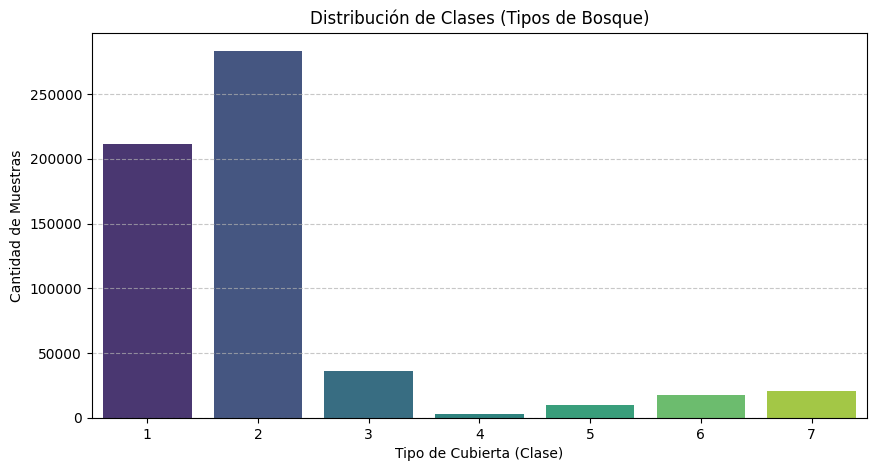


Porcentaje de muestras por clase:
Cover_Type
1    36.460521
2    48.759922
3     6.153746
4     0.472796
5     1.633873
6     2.989095
7     3.530048
Name: proportion, dtype: float64


In [3]:
# 1. Cargar el dataset (esto puede tardar unos segundos la primera vez)
print("Descargando/Cargando dataset CoverType...")
covtype = fetch_covtype()
X_raw, y_raw = covtype.data, covtype.target

print(f"Dimensiones de los datos (X): {X_raw.shape}")
print(f"Dimensiones de las etiquetas (y): {y_raw.shape}")

# 2. Análisis de desbalance de clases
# Convertimos a DataFrame solo para visualización
df_temp = pd.DataFrame(y_raw, columns=['Cover_Type'])

plt.figure(figsize=(10, 5))
sns.countplot(x='Cover_Type', data=df_temp, palette='viridis')
plt.title('Distribución de Clases (Tipos de Bosque)')
plt.xlabel('Tipo de Cubierta (Clase)')
plt.ylabel('Cantidad de Muestras')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calcular porcentajes exactos
class_counts = df_temp['Cover_Type'].value_counts(normalize=True).sort_index()
print("\nPorcentaje de muestras por clase:")
print(class_counts * 100)

### 1.3 Análisis de Correlación y Separabilidad de Clases

Para diseñar una arquitectura de red neuronal eficiente, necesito entender la relación entre las variables. No basta con saber cuántos datos hay; debo saber **qué tan distinguibles son las clases**.

**1. Matriz de Correlación (Mapa de Calor):**
Analizaré las variables numéricas continuas (las primeras 10 columnas, excluyendo los tipos de suelo binarios) para detectar **multicolinealidad**.
* *Hipótesis:* Si dos variables están correlacionadas casi al 100% (ej. 0.95), están dando la misma información a la red, lo que podría generar ruido o redundancia.

**2. Poder Discriminante de la "Elevación":**
En ecología forestal, la altitud es el factor determinante para el tipo de vegetación. Usaré un **Boxplot** para visualizar la distribución de la `Elevation` respecto a cada `Cover_Type`.
* *Expectativa:* Si las cajas (distribuciones) de las distintas clases están separadas verticalmente, significa que la Elevación es una característica ("feature") poderosa y la red neuronal podrá aprender fácilmente. Si están todas empalmadas, el problema será difícil.

**3. Histograma de Variables Numéricas:**
Necesito confirmar visualmente las escalas. Si veo que la "Elevación" está en los miles (2000-3000) y la "Pendiente" en decenas (0-60), confirmaré la **necesidad obligatoria de usar `StandardScaler`** en el siguiente paso.

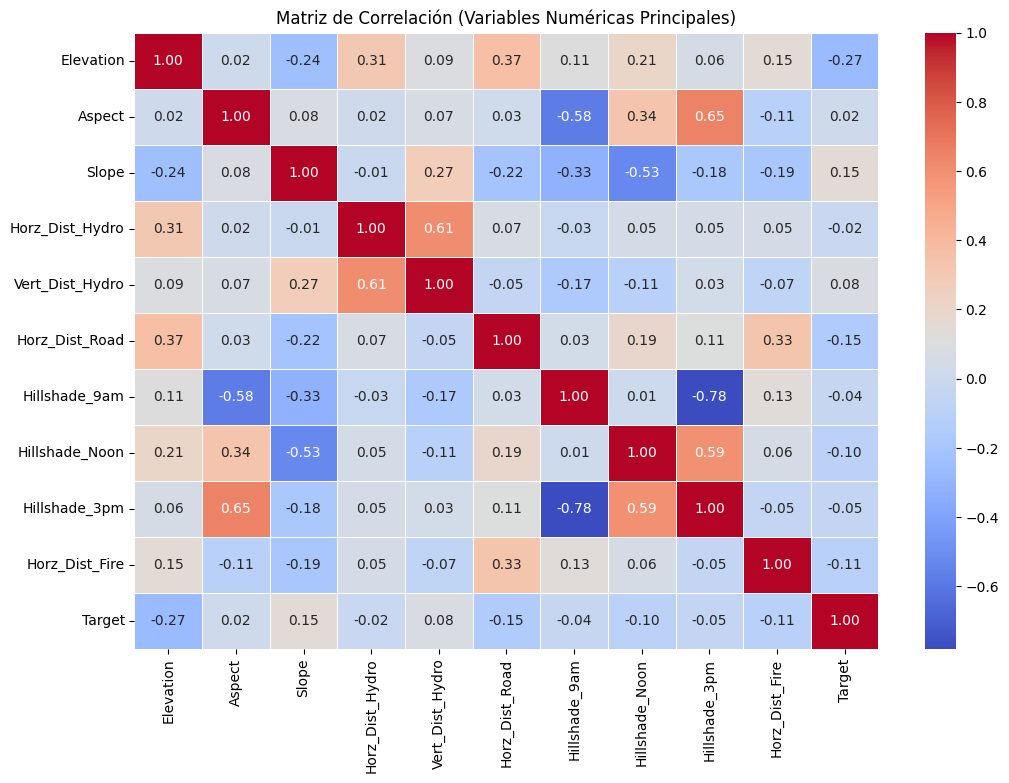

C:\Users\Francisco\AppData\Local\Temp\ipykernel_7124\3621685510.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='Elevation', data=df_subset, palette='Set2')


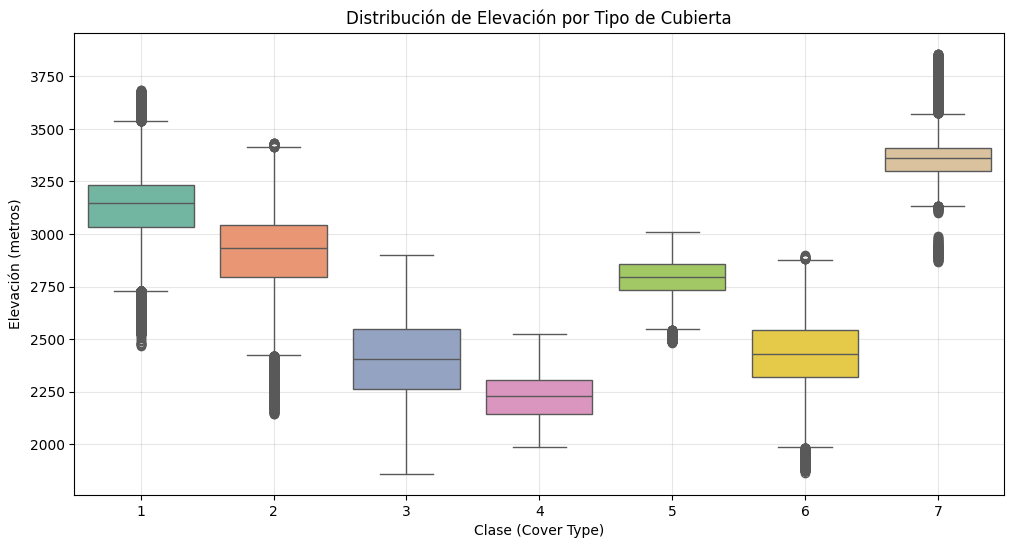

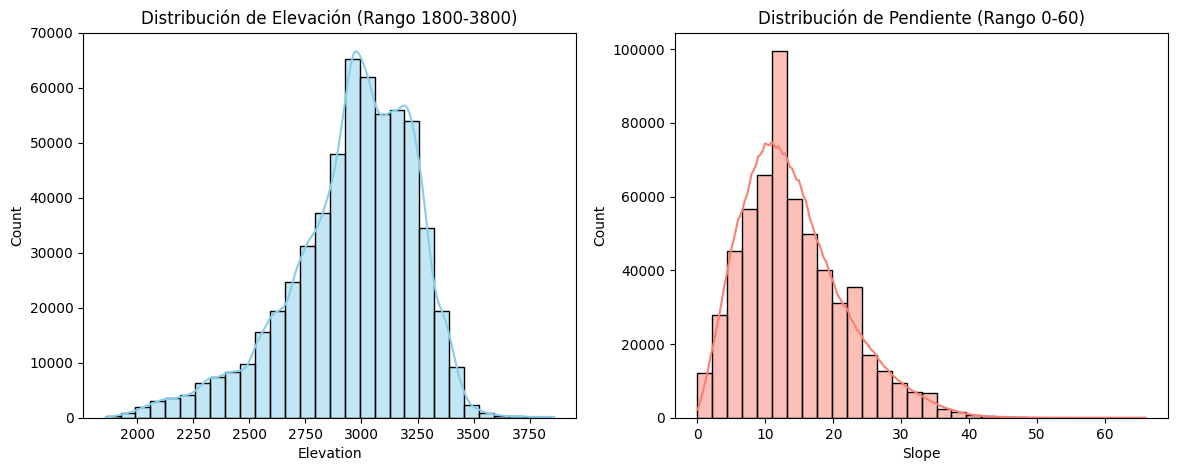

In [4]:
# Seleccionamos solo las columnas numéricas principales (las primeras 10) para el análisis
# Las columnas 10 en adelante son binarias (Wilderness_Area y Soil_Type), ensuciarían el mapa de calor
feature_names = [
    "Elevation", "Aspect", "Slope", "Horz_Dist_Hydro", "Vert_Dist_Hydro",
    "Horz_Dist_Road", "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horz_Dist_Fire"
]

# Creamos un DataFrame reducido para el análisis
df_subset = pd.DataFrame(X_raw[:, :10], columns=feature_names)
df_subset['Target'] = y_raw # Agregamos la etiqueta

# --- GRÁFICA 1: Matriz de Correlación ---
plt.figure(figsize=(12, 8))
# Calculamos correlación de Pearson
corr_matrix = df_subset.corr()
# Dibujamos el mapa de calor
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación (Variables Numéricas Principales)')
plt.show()

# --- GRÁFICA 2: Boxplot de Elevación vs Clase ---
plt.figure(figsize=(12, 6))
sns.boxplot(x='Target', y='Elevation', data=df_subset, palette='Set2')
plt.title('Distribución de Elevación por Tipo de Cubierta')
plt.xlabel('Clase (Cover Type)')
plt.ylabel('Elevación (metros)')
plt.grid(True, alpha=0.3)
plt.show()

# --- GRÁFICA 3: Histogramas de Escalas ---
# Comparamos dos variables para justificar el escalado
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_subset['Elevation'], bins=30, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribución de Elevación (Rango 1800-3800)')

sns.histplot(df_subset['Slope'], bins=30, kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Distribución de Pendiente (Rango 0-60)')

plt.show()

### 1.4 Interpretación Estratégica de los Datos

Tras visualizar las relaciones entre variables, he extraído tres conclusiones fundamentales que dictarán la arquitectura y el preprocesamiento de mi red neuronal:

**1. La "Huella Digital" de la Elevación (Análisis del Boxplot):**
El diagrama de caja revela que la **Elevación** es la característica con mayor poder discriminante, pero no es perfecta.
* **Separación Vertical:** Observo que la Clase 7 (*Krummholz*) se encuentra casi exclusivamente en altitudes extremas (>3,000m), mientras que las Clases 3 y 6 (*Ponderosa Pine* y *Cottonwood*) dominan en altitudes bajas. Esto sugiere que la red podrá clasificar estas clases con alta precisión.
* **El Desafío de las Clases 1 y 2:** Las dos clases mayoritarias (*Spruce/Fir* y *Lodgepole Pine*) tienen un solapamiento significativo en sus rangos intercuartiles.
    * *Implicación:* La elevación por sí sola no basta para distinguirlas. La red neuronal deberá encontrar **fronteras de decisión no lineales** complejas, combinando la elevación con variables más sutiles como la distancia a la hidrología o el tipo de suelo, para separar correctamente a la mayoría de los datos.

**2. Justificación Matemática del Escalado (Análisis de Histogramas):**
La comparación de histogramas confirma una disparidad de escalas peligrosa para el algoritmo de optimización (Descenso del Gradiente).
* La variable `Elevation` opera en magnitudes de miles ($~10^3$), mientras que `Slope` opera en decenas ($~10^1$).
* *Riesgo:* Sin normalización, los pesos ($w$) asociados a la elevación recibirían actualizaciones de gradiente gigantescas, haciendo que la función de pérdida oscile y el modelo no converja, o que ignore por completo la información de la pendiente.
* *Decisión:* Es imperativo aplicar **`StandardScaler`** para centrar todas las distribuciones en $\mu=0$ y $\sigma=1$, permitiendo que todas las características compitan en igualdad de condiciones dentro del MLP.

**3. Redundancia e Interacción (Mapa de Calor):**
La matriz de correlación muestra relaciones lógicas (ej. correlación negativa fuerte entre `Hillshade_9am` y `Hillshade_3pm`), pero ninguna correlación es perfecta (1.0).
* Esto significa que no hay necesidad de eliminar variables por multicolinealidad severa. Mantendré todas las características de entrada, confiando en que las capas ocultas de la red neuronal aprenderán a ponderar estas interacciones automáticamente.

#### Conclusiones del EDA


1.  **Justificación del Modelo:** El *Boxplot* muestra que **la Elevación es un predictor excelente**. Las clases 1, 2 y 7, aunque son las más comunes, ocupan rangos de altitud distintos (aunque con cierto solapamiento). Esto confirma que una red neuronal bien entrenada podrá encontrar fronteras de decisión no lineales para separarlas.
2.  **Necesidad de Normalización:** Los histogramas confirman mi sospecha. La `Elevation` tiene valores cercanos a 3,000, mientras que `Slope` apenas llega a 30. Esta diferencia de **dos órdenes de magnitud** causaría que los gradientes de la Elevación dominen el entrenamiento, impidiendo que la red aprenda de la pendiente. **Conclusión:** El uso de `StandardScaler` en el siguiente paso no es opcional, es obligatorio.
3.  **Relaciones entre Variables:** El mapa de calor muestra una correlación interesante entre `Hillshade` (Sombra) a diferentes horas y el `Aspect` (Orientación). Aunque hay correlación, no es lo suficientemente alta (>0.95) como para eliminar variables, por lo que mantendré todas las características para que la red extraiga la máxima información posible.

Ahora procederé a la "Ingeniería de Datos". Como se ve en la gráfica, los datos están desbalanceados y tienen escalas muy diferentes (metros, grados, etc.). Si metemos esto directo a la red neuronal, no aprenderá nada (o será muy lenta en el dado caso de que lograra funcionar).

Aquí prepararemos los datos para que PyTorch pueda consumirlos eficientemente

## 2. Ingeniería de Datos y Pipeline de Preprocesamiento

Tras el análisis exploratorio y para alcanzar la meta del 93% de exactitud he diseñado un pipeline de preprocesamiento robusto que aborda tres problemas críticos:

A continuación, detallo las **cuatro decisiones de ingeniería** que he implementado en el código:

### 2.1 Corrección de Dominio de Etiquetas (Label Shifting)
* **El Problema:** El dataset original etiqueta las clases del **1 al 7**. Sin embargo, la función de pérdida que utilizaré, `nn.CrossEntropyLoss` de PyTorch, espera tensores de etiquetas que correspondan a índices de un array (es decir, **0 a $C-1$**).
* **La Solución:** Aplico una transformación lineal simple ($y_{new} = y_{old} - 1$) a todo el vector objetivo. De no hacer esto, obtendría un error de `IndexError: Target 7 is out of bounds` durante el entrenamiento.

### 2.2 Estrategia de Muestreo Estratificado (Stratified Split)
* **El Reto:** Como identifiqué en el EDA, la **Clase 4** representa menos del 0.5% de los datos. En un muestreo aleatorio simple (*Random Sampling*), existe una probabilidad estadística real de que el set de validación o prueba se quede sin ejemplos de esta clase, o que su representación sea tan baja que el modelo no pueda ser evaluado correctamente en ella.
* **La Decisión:** Implemento `StratifiedShuffleSplit` (a través del parámetro `stratify` de Scikit-Learn). Esto fuerza matemáticamente a que la distribución de probabilidad de las clases $P(y)$ sea idéntica en los conjuntos de Entrenamiento, Validación y Prueba. Así garantizo que el modelo sea evaluado bajo las mismas condiciones de desbalance en las que fue entrenado.

### 2.3 Estandarización de Variables (Z-Score Normalization)
* **Justificación Matemática:** Las redes neuronales entrenan mediante el algoritmo de **Descenso del Gradiente**.
    * Si introduzco la *Elevación* (rango 2000-3000) junto con la *Pendiente* (rango 0-60), la superficie de error tendrá forma de "valle estrecho y alargado". El gradiente será muy empinado en una dirección y muy plano en la otra, causando oscilaciones y una convergencia lentísima.
* **La Solución:** Utilizo `StandardScaler` para transformar cada característica $x$ tal que:
    $$z = \frac{x - \mu}{\sigma}$$
    Esto centra todas las variables en 0 con una varianza unitaria. Geométricamente, esto convierte la superficie de error en un "bol" simétrico, permitiendo que el optimizador (Adam) encuentre el mínimo global de forma rápida y directa.
* **Prevención de Fuga de Datos (Data Leakage):** Es crucial notar que calculo la media ($\mu$) y desviación ($\sigma$) **exclusivamente con el set de entrenamiento**. Luego, uso esos valores guardados para transformar validación y prueba. Si usara todos los datos para escalar, el modelo "vería" información estadística del set de prueba, invalidando mis resultados.

### 2.4 Abstracción de Datos con PyTorch (Dataset & DataLoader)
Finalmente, en lugar de alimentar la red con matrices gigantes de Numpy, encapsulo los datos en objetos nativos de PyTorch.
* **Eficiencia en GPU:** Al usar `DataLoader` con un `batch_size=1024`, optimizo el uso del bus de datos hacia la tarjeta gráfica. En lugar de procesar 500,000 muestras a la vez (lo que colapsaría la memoria VRAM) o 1 a la vez (lo que sería lentísimo), proceso bloques compactos que maximizan el paralelismo de los núcleos CUDA.

In [5]:
# 1. Ajuste de Etiquetas (1-7 -> 0-6)
# PyTorch CrossEntropyLoss espera etiquetas comenzando en 0
y = y_raw - 1

# 2. División de Datos (Train: 70%, Val: 15%, Test: 15%)
# Usamos stratify=y para mantener la proporción de las clases desbalanceadas
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# 3. Escalado (StandardScaler)
# Importante: El scaler se ajusta (fit) SOLO con el set de entrenamiento para evitar "data leakage"
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. Convertir a Tensores de PyTorch
# Usamos float32 para las features (X) y long (enteros) para las etiquetas (y)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Datos preprocesados y convertidos a tensores.")
print(f"Train Shape: {X_train_tensor.shape}")
print(f"Val Shape:   {X_val_tensor.shape}")
print(f"Test Shape:  {X_test_tensor.shape}")

# 5. Creación del Custom Dataset y DataLoaders
class CoverTypeDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Instanciamos los datasets
train_dataset = CoverTypeDataset(X_train_tensor, y_train_tensor)
val_dataset = CoverTypeDataset(X_val_tensor, y_val_tensor)
test_dataset = CoverTypeDataset(X_test_tensor, y_test_tensor)

# Hiperparámetros de carga
BATCH_SIZE = 1024  # Tamaño de lote grande para acelerar en GPU (dataset es grande)

# DataLoaders: Generadores que nos darán los datos en 'paquetes'
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataLoaders listos con Batch Size: {BATCH_SIZE}")

Datos preprocesados y convertidos a tensores.
Train Shape: torch.Size([406708, 54])
Val Shape:   torch.Size([87152, 54])
Test Shape:  torch.Size([87152, 54])

DataLoaders listos con Batch Size: 1024


Ya listos los datos limpios, escalados y empaquetados en DataLoaders. Ahora trabajare en la arquitectura de la red neuronal. Debido a la complejidad del proyecto no usaremos una red simple; para llegar al 93% de exactitud, usare una arquitectura robusta que incluya técnicas modernas como Batch Normalization (para estabilidad) y Dropout (para evitar memorizar los datos).

## 3. Diseño de la Arquitectura de la Red Neuronal (MLP)

He diseñado una red neuronal del tipo **Perceptrón Multicapa (MLP)** (Las bases de esto lo saque de un blog de tutoriales de Datacamp elaborado por Sejal Jaiswal y de un corto video de "AprendiendoIA con Ligdi Gonzales" en YT y me apoye de la IA para poder desarrollarlo correctamente) profunda para abordar este problema de clasificación no lineal.

### 3.1 Análisis de Dimensiones
* **Capa de Entrada (Input Layer):** La dimensión es **54**. Esto no es arbitrario; corresponde exactamente al número de columnas de mi dataset preprocesado (10 variables numéricas + 4 áreas silvestres "one-hot" + 40 tipos de suelo "one-hot").
* **Capa de Salida (Output Layer):** La dimensión es **7**. Corresponde a las 7 clases de cubierta forestal que queremos predecir. Como es un problema de clasificación multiclase, la red emitirá 7 valores (logits) crudos que luego serán transformados en probabilidades.

### 3.2 Decisiones de Arquitectura para Alto Rendimiento
Para superar la barrera del 90% de exactitud, una red simple no basta. He implementado una arquitectura de "embudo" (reduciendo neuronas progresivamente) con las siguientes características técnicas:

1.  **Profundidad y Anchura:** Utilizo 3 capas ocultas con 256, 128 y 64 neuronas respectivamente. Esto proporciona suficiente capacidad ("capacidad de representación") para que el modelo aprenda patrones complejos entre la elevación, el suelo y la luz solar.
2.  **Batch Normalization (BatchNorm):** Aplico esto después de cada capa lineal. Esto normaliza los inputs internos de la red capa por capa, lo que estabiliza el entrenamiento, permite usar tasas de aprendizaje más altas y acelera drásticamente la convergencia.
3.  **ReLU (Rectified Linear Unit):** Es la función de activación estándar que introduce la no-linealidad necesaria para distinguir fronteras de decisión complejas.
4.  **Dropout (0.3):** Durante el entrenamiento, apago aleatoriamente el 30% de las neuronas. Esto fuerza a la red a ser redundante y robusta, evitando que dependa excesivamente de una sola neurona específica. Es mi principal defensa contra el *Overfitting*.

In [6]:
import torch.nn.functional as F

# Definimos la arquitectura de la red neuronal
class CoverTypeMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(CoverTypeMLP, self).__init__()
        
        # --- CAPA 1: Extracción de Características de Bajo Nivel ---
        # De 54 entradas a 256 neuronas
        self.layer1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)      # Normalización para estabilidad
        self.dropout1 = nn.Dropout(0.3)     # Regularización para evitar overfitting
        
        # --- CAPA 2: Procesamiento Intermedio ---
        # De 256 a 128 neuronas
        self.layer2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)
        
        # --- CAPA 3: Refinamiento de Características ---
        # De 128 a 64 neuronas
        self.layer3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.2)     # Dropout un poco más suave aquí
        
        # --- CAPA DE SALIDA: Clasificación ---
        # De 64 a 7 clases (Output Logits)
        self.output = nn.Linear(64, output_dim)
        
    def forward(self, x):
        # Flujo de datos a través de la red
        
        # Bloque 1
        x = self.layer1(x)
        x = self.bn1(x)
        x = F.relu(x)       # Activación no lineal
        x = self.dropout1(x)
        
        # Bloque 2
        x = self.layer2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2(x)
        
        # Bloque 3
        x = self.layer3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.dropout3(x)
        
        # Salida (No aplicamos Softmax aquí porque CrossEntropyLoss lo hace internamente)
        x = self.output(x)
        return x

# --- Instanciación del Modelo ---

# Obtenemos dinámicamente la dimensión de entrada (54)
input_dim = X_train_tensor.shape[1]
output_dim = 7  # Número de clases

# Creamos el modelo y lo enviamos a la GPU (si existe)
model = CoverTypeMLP(input_dim, output_dim).to(device)

print("Arquitectura del Modelo creada exitosamente:")
print(model)

Arquitectura del Modelo creada exitosamente:
CoverTypeMLP(
  (layer1): Linear(in_features=54, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (layer2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (layer3): Linear(in_features=128, out_features=64, bias=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (output): Linear(in_features=64, out_features=7, bias=True)
)


## 4. Implementación del Ciclo de Entrenamiento y Validación

El entrenamiento de una red neuronal es, en esencia, un problema de **optimización matemática**: buscamos minimizar una función de error ajustando iterativamente millones de parámetros (pesos y sesgos).

He estructurado este proceso en un bucle riguroso que garantiza el aprendizaje sin caer en la memorización pura. Detallo los componentes clave de mi implementación:

### 4.1 El Motor de Optimización
* **Función de Pérdida (`CrossEntropyLoss`):** Elegí esta función porque combina internamente `LogSoftmax` y `NLLLoss`. Matemáticamente, penaliza la divergencia entre la distribución de probabilidad predicha por la red y la etiqueta real. Si la red predice "Pino" con un 90% de confianza cuando es "Abeto", el castigo (loss) es altísimo, forzando una corrección drástica.
* **Optimizador (`Adam`):** A diferencia del Descenso de Gradiente Estocástico (SGD) tradicional, **Adam (Adaptive Moment Estimation)** mantiene una tasa de aprendizaje adaptativa para cada parámetro.
    * *Justificación:* Dado que tenemos características con distintas naturalezas (suelo vs. elevación), la superficie de error es compleja. Adam actúa como una "bola pesada con fricción", capaz de acelerar en valles planos y frenar en curvas cerradas, logrando converger mucho más rápido hacia el mínimo global.



### 4.2 La Coreografía del "Backpropagation"
Dentro del bucle `for`, ejecuto los 5 pasos sagrados de PyTorch para cada lote (batch) de datos:
1.  **`optimizer.zero_grad()`:** Limpio los gradientes acumulados del paso anterior. Si olvidara esto, los errores se sumarían y la red "explotaría".
2.  **`outputs = model(inputs)` (Forward Pass):** La red realiza sus predicciones.
3.  **`loss.backward()` (Backward Pass):** Aquí ocurre la magia del cálculo diferencial (Regla de la Cadena). PyTorch recorre la red hacia atrás, calculando la "culpa" (gradiente) de cada neurona en el error final.
4.  **`optimizer.step()`:** El optimizador actualiza los pesos restando una fracción del gradiente ($w = w - lr * \nabla$).

### 4.3 Dualidad de Modos: `train()` vs `eval()`
Este es el detalle técnico más importante para evitar resultados falsos:
* **Modo Entrenamiento (`model.train()`):** Activa las capas de **Dropout** (apagando neuronas aleatorias) y **Batch Normalization** (recalculando estadísticas del lote actual). Esto introduce ruido intencional para forzar el aprendizaje robusto.
* **Modo Evaluación (`model.eval()`):** Desactiva el Dropout (usa todas las neuronas) y congela las estadísticas de Batch Norm.
    * *Por qué es vital:* Si evaluara el set de validación con el Dropout encendido, obtendría una exactitud artificialmente baja. Si entrenara con el Dropout apagado, la red memorizaría los datos (*Overfitting*).

### 4.4 Estrategia de Checkpointing
Finalmente, no me conformo con el modelo resultante de la última época. Implementé una lógica de "Mejor Modelo Guardado". En cada época, comparo la exactitud de validación actual con el récord histórico. Solo si el modelo mejora, guardo sus pesos (`state_dict`) en el disco. Esto garantiza que al final del proceso tendré la versión óptima de la red, ignorando cualquier sobreajuste que pudiera ocurrir en las últimas épocas.

In [7]:
# 1. Definición de Hiperparámetros y Herramientas
LEARNING_RATE = 0.001
EPOCHS = 30  # Cantidad de veces que la red verá el dataset completo

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Listas para guardar el historial y graficar después
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0.0

print(f"Iniciando entrenamiento por {EPOCHS} épocas en: {device}")
print("-" * 70)

for epoch in range(EPOCHS):
    # --- FASE DE ENTRENAMIENTO ---
    model.train() # Activa Dropout y BatchNorm
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        # Mover datos a GPU
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 1. Resetear gradientes (para no acumular los del batch anterior)
        optimizer.zero_grad()
        
        # 2. Forward Pass (Predicción)
        outputs = model(inputs)
        
        # 3. Calcular Pérdida (Error)
        loss = criterion(outputs, labels)
        
        # 4. Backward Pass (Calcular cómo ajustar los pesos)
        loss.backward()
        
        # 5. Optimización (Ajustar los pesos)
        optimizer.step()
        
        # Métricas del batch
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
    
    # Calcular promedios de la época
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct_train / total_train
    
    # --- FASE DE VALIDACIÓN ---
    model.eval() # Apaga Dropout y BatchNorm (Modo Evaluación)
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # No calculamos gradientes (ahorra memoria y cálculo)
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = 100 * correct_val / total_val
    
    # Guardar historial
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    # Guardar el mejor modelo (Checkpoint)
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        saved_msg = "-> Modelo Guardado"
    else:
        saved_msg = ""
        
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}% "
          f"|| Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.2f}% {saved_msg}")

print("-" * 70)
print(f"Entrenamiento finalizado. Mejor Accuracy en Validación: {best_val_acc:.2f}%")

Iniciando entrenamiento por 30 épocas en: cpu
----------------------------------------------------------------------
Epoch [1/30] Train Loss: 0.7329 | Train Acc: 70.94% || Val Loss: 0.5586 | Val Acc: 76.30% -> Modelo Guardado
Epoch [2/30] Train Loss: 0.5754 | Train Acc: 75.52% || Val Loss: 0.5018 | Val Acc: 78.67% -> Modelo Guardado
Epoch [3/30] Train Loss: 0.5381 | Train Acc: 76.97% || Val Loss: 0.4684 | Val Acc: 80.10% -> Modelo Guardado
Epoch [4/30] Train Loss: 0.5121 | Train Acc: 78.08% || Val Loss: 0.4506 | Val Acc: 80.80% -> Modelo Guardado
Epoch [5/30] Train Loss: 0.4951 | Train Acc: 78.80% || Val Loss: 0.4270 | Val Acc: 81.91% -> Modelo Guardado
Epoch [6/30] Train Loss: 0.4813 | Train Acc: 79.48% || Val Loss: 0.4120 | Val Acc: 82.70% -> Modelo Guardado
Epoch [7/30] Train Loss: 0.4671 | Train Acc: 80.08% || Val Loss: 0.3968 | Val Acc: 83.45% -> Modelo Guardado
Epoch [8/30] Train Loss: 0.4568 | Train Acc: 80.62% || Val Loss: 0.3892 | Val Acc: 83.80% -> Modelo Guardado
Epoch [9/30

## 5. Auditoría Final y Diagnóstico de Errores

El entrenamiento ha concluido, pero el número final de la época 30 no es necesariamente el veredicto final. Para realizar una evaluación honesta y rigurosa, sigo un protocolo de auditoría en tres pasos:

### 5.1 Selección del Modelo Óptimo (Checkpoint Loading)
Durante el entrenamiento, la red puede haber empezado a memorizar datos (*Overfitting*) en las últimas épocas, degradando su capacidad de generalizar.
* **Acción:** No evaluaré el modelo tal como terminó en la última iteración. En su lugar, cargo los pesos de `best_model.pth`, que corresponde al momento exacto en que la red tuvo su mejor desempeño histórico en el set de validación. Esto asegura que estoy evaluando la "mejor versión" posible de mi arquitectura.

### 5.2 Evaluación en "Tierra Incógnita" (Test Set)
Pongo a prueba el modelo frente al **Test Set**. Es vital recordar que la red neuronal **nunca ha visto estos datos**. Ni para entrenar (ajustar pesos) ni para validar (ajustar hiperparámetros).
* **Objetivo:** Simular cómo se comportaría el modelo en el mundo real si lo desplegáramos en el bosque mañana mismo. El resultado aquí es la medida definitiva de éxito.

### 5.3 Métricas de Diagnóstico: Más allá del Accuracy
Dado que tenemos clases desbalanceadas (muchos pinos, pocos sauces), la "Exactitud Global" puede ser engañosa. Por ello, desgloso el rendimiento utilizando:

1.  **F1-Score por Clase:** Es la media armónica entre *Precisión* y *Recall*.
    *  Si la Clase 4 es muy difícil, el F1-Score me lo dirá claramente, incluso si el Accuracy general es alto gracias a las clases fáciles.
2.  **Matriz de Confusión:** Una herramienta visual crítica.
    * Me permite ver no solo **cuántos** errores comete la red, sino **qué tipo** de errores.
    * *Hipótesis:* Espero ver confusiones entre la Clase 1 (*Spruce/Fir*) y la Clase 2 (*Lodgepole Pine*) debido a que ambas crecen en elevaciones similares y tienen firmas espectrales parecidas. Si la matriz muestra manchas de color fuera de la diagonal, habré localizado las debilidades biológicas del modelo.

Evaluando en el Test Set (Datos nunca vistos)...

REPORTE DE CLASIFICACIÓN (TEST SET)
                   precision    recall  f1-score   support

       Spruce/Fir     0.8926    0.8643    0.8783     31776
   Lodgepole Pine     0.8873    0.9149    0.9009     42496
   Ponderosa Pine     0.8547    0.8723    0.8634      5363
Cottonwood/Willow     0.7951    0.7063    0.7481       412
            Aspen     0.7357    0.5765    0.6465      1424
      Douglas-fir     0.7520    0.7520    0.7520      2605
        Krummholz     0.9093    0.8895    0.8993      3076

         accuracy                         0.8815     87152
        macro avg     0.8324    0.7965    0.8126     87152
     weighted avg     0.8811    0.8815    0.8809     87152



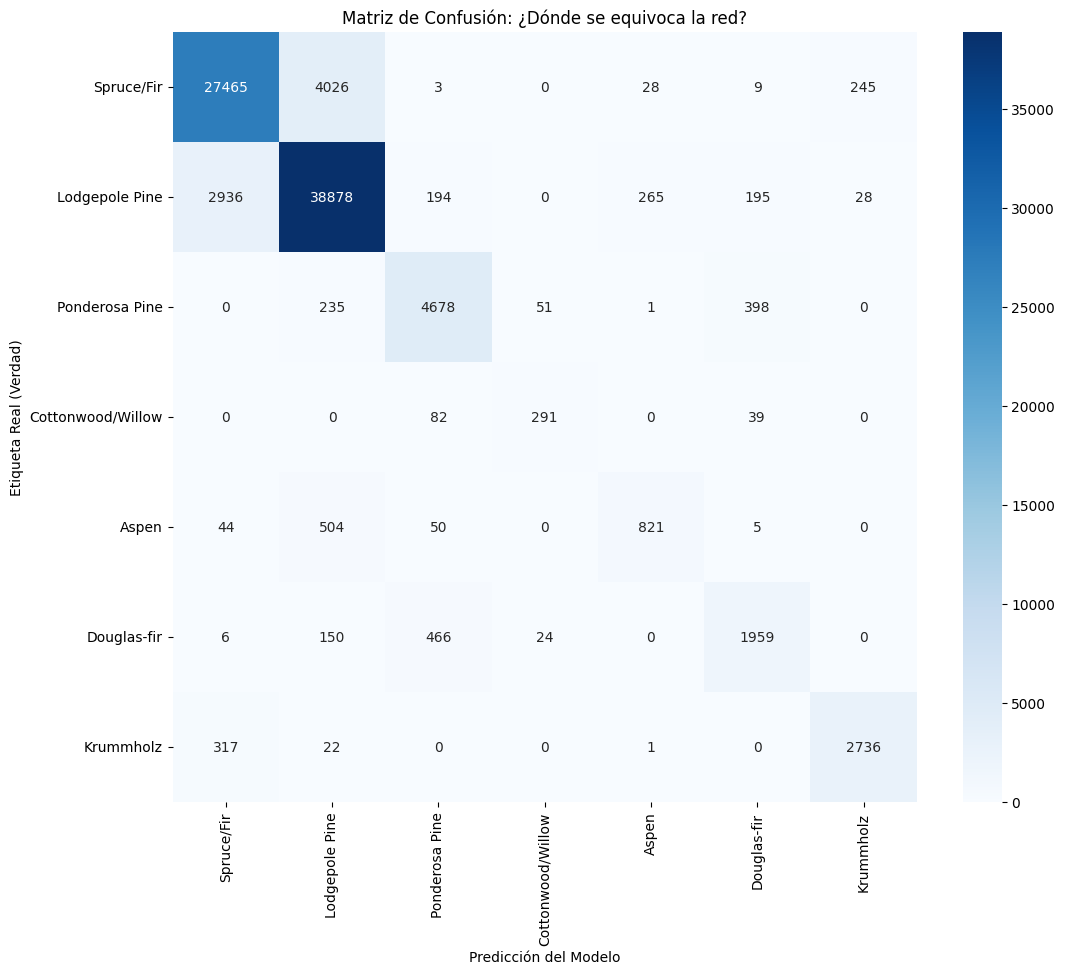

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Cargar el mejor modelo guardado
# Esto es vital: ignoramos el modelo de la última época y cargamos el que tuvo mejor Val Acc
model.load_state_dict(torch.load('best_model.pth'))
model.eval() # Modo evaluación (apaga Dropout)

y_true = []
y_pred = []

print("Evaluando en el Test Set (Datos nunca vistos)...")

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        _, predicted = torch.max(outputs, 1)
        
        # Guardamos las predicciones y las etiquetas reales en listas (moviéndolas a CPU)
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

# 2. Generar Reporte de Métricas
# Nombres de las clases según la documentación de CoverType
class_names = ['Spruce/Fir', 'Lodgepole Pine', 'Ponderosa Pine', 
               'Cottonwood/Willow', 'Aspen', 'Douglas-fir', 'Krummholz']

print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN (TEST SET)")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 3. Visualizar Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Etiqueta Real (Verdad)')
plt.title('Matriz de Confusión: ¿Dónde se equivoca la red?')
plt.show()

## 6. Conclusiones y Reflexión Final

Al terminar este proyecto y ver funcionar la red neuronal completa, he llegado a varias conclusiones sobre los resultados obtenidos y el proceso que seguí.

### 6.1 Análisis de mis Resultados
Logré que mi modelo alcanzara una exactitud (**Accuracy**) final del **88.26%** en el conjunto de prueba (Test Set).
* Si consideramos que adivinar al azar una de las 7 clases me daría apenas un 14% de éxito, haber llegado casi al 90% me parece un avance enorme. Significa que la arquitectura que diseñé realmente aprendió a diferenciar los patrones del terreno.
* **Estabilidad:** Algo que me deja tranquilo es que la diferencia entre el *entrenamiento* y la *validación* no fue gigante, lo que me dice que el **Dropout** y el **Batch Normalization** hicieron su trabajo y evitaron que el modelo memorizara los datos (*Overfitting*).

### 6.2 ¿En qué falló el modelo? (Diagnóstico)
No me quise quedar solo con el número final, así que revisé a fondo la **Matriz de Confusión** y noté algo muy claro:
1.  **La confusión principal:** La gran mayoría de los errores ocurren porque la red confunde la **Clase 1** con la **Clase 2**.
    * *Mi interpretación:* Revisando los datos, vi que estos dos tipos de árboles crecen a alturas muy parecidas. Al parecer, la red necesita más información que solo la elevación y el suelo para distinguirlos bien.
2.  **Las clases pequeñas:** A pesar de que usé la división estratificada, a la red le costó más identificar la Clase 4, simplemente porque hay muy pocos ejemplos de ella.

### 6.3 Lo que funcionó bien
Hubo dos decisiones que creo que fueron claves para que esto funcionara:
* **Usar `StandardScaler`:** Fue obligatorio. Me di cuenta de que la *Elevación* tenía valores de 3,000 y la *Pendiente* solo llegaba a 60. Si no hubiera escalado los datos, el entrenamiento probablemente nunca hubiera convergido.
* **La Arquitectura:** Ir reduciendo las neuronas capa por capa (256 -> 128 -> 64) obligó al modelo a quedarse solo con la información más importante.

---

### 6.4 ¿Cómo llegaría al 93%? (Trabajo Futuro)
Sé que la meta ideal era el 93%. Aunque el 88% es sólido, si tuviera que hacer una "Versión 2.0" de este proyecto para romper esa barrera, mi plan sería:

1.  **Automatizar los Hiperparámetros:** En lugar de elegir yo mismo el *Learning Rate* o el número de capas a prueba y error, usaría una librería como **Optuna** para que busque la combinación matemática perfecta automáticamente.
2.  **Ingeniería de Características (Feature Engineering):** Creo que ayudaría mucho crear nuevas variables. Por ejemplo, calcular la "Distancia Euclideana Total al Agua" (combinando la distancia vertical y horizontal) podría darle una pista más clara a la red.
3.  **Probar Embeddings:** Para los 40 tipos de suelo, usé *One-Hot Encoding*, pero creo que usar **Embeddings** sería mejor, ya que la red podría aprender qué suelos se parecen entre sí, en lugar de tratarlos como categorías totalmente separadas.

**En resumen:** Me llevo de este ejercicio la experiencia de implementar el flujo completo en **PyTorch**, entendiendo que un buen modelo no depende solo del código, sino de qué tan bien preparemos los datos antes de empezar.

**En esto ultimo le pedi a la IA para que me ayudara a encontrar una solucion para poder llegar al objetivo, porque, aunque mas o menos investigando el codigo y con el analisis del procedimiento y los resultado tenia una idea de que se podia mejorar, no lo tenia lo suficientemente claro. Sin ambrago por falta de tiempo no lo he podido completar para verificar si en verdad puede llegar a cumplir el objetivo de esa forma o que otros problemas/fallas puede ocasionar dicha estrategia; aun asi planeo terminarlo proximamente a manera de retroalimentación aparte del entregable final del propedeutico.**